# PRCL-0017: Customer Churn Prediction Using Machine Learning

## Problem Statement

No-Churn Telecom is an established telecom operator facing increasing competition from new players in the market. Despite initiatives like reduced tariffs and promotional offers, the company's churn rate (percentage of customers migrating to competitors) remains above 10%.

The goal of this project is to analyze customer usage and demographic data, build a predictive model to identify customers likely to churn, determine which factors most strongly influence churn, and generate churn risk scores to help the business prioritize retention campaigns.

---

## Tasks

### Task 1: Data Analysis

Prepare a complete data analysis report on the telecom customer data by:

- Understanding the dataset structure and features.
- Identifying and handling missing values.
- Checking for outliers and duplicate records.
- Performing data cleaning and preprocessing.
- Analyzing correlations between features and Churn.
- Visualizing key trends and relationships.
- Generating meaningful insights from the data.

### Task 2: Predictive Model Development

Create a robust machine learning model to predict customer churn, and determine the relationship between customer features and churn. This should include:

- Feature engineering (creating new meaningful features, e.g. tenure_days).
- Encoding categorical variables (telecom_partner, state, city, gender).
- Handling class imbalance using SMOTE.
- Splitting data into training and testing sets.
- Training multiple predictive models (Logistic Regression, Random Forest).
- Evaluating models using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.
- Comparing model performance.
- Selecting the best-performing model.
- Identifying which features most influence Churn.

### Task 3: Retention Recommendations

Provide suggestions to the business on which customers to prioritize for retention campaigns based on their churn risk score, and highlight key behavioral drivers of churn (e.g. low usage, high customer service interaction, short tenure).

---

## Project Workflow

1. Import Required Libraries
2. Load the Dataset (from SQL database)
3. Understand the Dataset (shape, dtypes, summary statistics)
4. Identify and Handle Missing Values
5. Check for Outliers and Duplicate Records
6. Perform Data Cleaning
7. Feature Engineering (tenure_days, etc.)
8. Exploratory Data Analysis (EDA)
9. Analyze Correlations Between Features and Churn
10. Visualize Key Trends and Relationships
11. Prepare Data for Modeling (encoding, scaling, train-test split)
12. Handle Class Imbalance (SMOTE)
13. Train Multiple Predictive Models
14. Evaluate Model Performance (Accuracy, Precision, Recall, F1, ROC-AUC)
15. Compare Models and Select the Best-Performing One
16. Analyze Feature Importance
17. Generate Churn Risk Scores and CHURN_FLAG
18. Summarize Findings in Conclusion and Future Scope

---

## Target Variable

**Churn** – Indicates whether a customer left the company (1) or stayed (0). This is the value the model is trained to predict, based on the customer's demographic and usage features (calls made, SMS sent, data used, tenure, etc.).



 ## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

## Connect to SQL Database & Load Data

In [2]:

username = 'dm_team3'
password = 'DM!$!Team!27@9!20&'
host = '18.136.157.135'
database = 'project_telecom'
from urllib.parse import quote_plus
password_encoded = quote_plus(password)
engine = create_engine(f'mysql+pymysql://{username}:{password_encoded}@{host}/{database}')
df = pd.read_sql('SELECT * FROM telecom_churn_data', engine)
df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


## Basic Info & Shape

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (243553, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   customer_id           243553 non-null  int64 
 1   telecom_partner       243553 non-null  object
 2   gender                243553 non-null  object
 3   age                   243553 non-null  int64 
 4   state                 243553 non-null  object
 5   city                  243553 non-null  object
 6   pincode               243553 non-null  int64 
 7   date_of_registration  243553 non-null  object
 8   num_dependents        243553 non-null  int64 
 9   estimated_salary      243553 non-null  int64 
 10  calls_made            243553 non-null  int64 
 11  sms_sent              243553 non-null  int64 
 12  data_used             243553 non-null  int64 
 13  churn                 243553 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 26.0+ MB


## Check for Missing Values & Duplicates

In [4]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

Duplicate rows: 0


## Target Variable Distribution

churn
0    194726
1     48827
Name: count, dtype: int64
churn
0    79.952208
1    20.047792
Name: proportion, dtype: float64


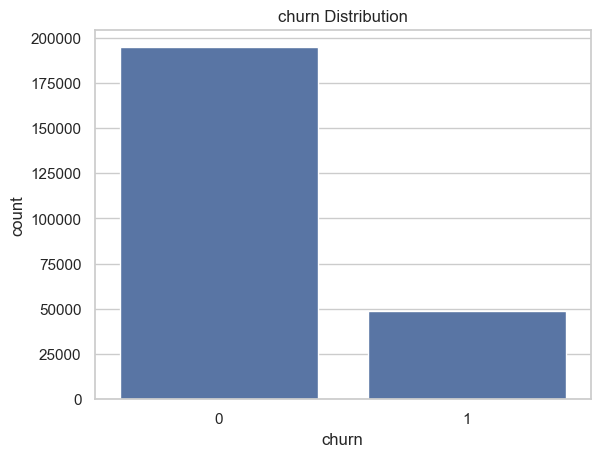

In [5]:
print(df['churn'].value_counts())
print(df['churn'].value_counts(normalize=True) * 100)

sns.countplot(x='churn', data=df)
plt.title('churn Distribution')
plt.show()

In [6]:
print(df.columns.tolist())

['customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city', 'pincode', 'date_of_registration', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'churn']


## Drop Irrelevant Columns

In [7]:

df.drop(['customer_id'], axis=1, inplace=True)
df.head()

,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


## Encode Categorical Variables

In [8]:

print(df['churn'].unique())
print(df['telecom_partner'].unique())
print(df['gender'].unique())

[0 1]
['Reliance Jio' 'Vodafone' 'BSNL' 'Airtel']
['F' 'M']


In [9]:

if df['churn'].dtype == 'object':
    df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].map({'M': 1, 'F': 0})
df['date_of_registration'] = pd.to_datetime(df['date_of_registration'])
df['tenure_days'] = (pd.Timestamp.today() - df['date_of_registration']).dt.days
df.drop(['date_of_registration'], axis=1, inplace=True)
df = pd.get_dummies(df, columns=['telecom_partner', 'state', 'city'], drop_first=True)
df.head()

,gender,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,tenure_days,telecom_partner_BSNL,telecom_partner_Reliance Jio,telecom_partner_Vodafone,state_Arunachal Pradesh,state_Assam,state_Bihar,state_Chhattisgarh,state_Goa,state_Gujarat,state_Haryana,state_Himachal Pradesh,state_Jharkhand,state_Karnataka,state_Kerala,state_Madhya Pradesh,state_Maharashtra,state_Manipur,state_Meghalaya,state_Mizoram,state_Nagaland,state_Odisha,state_Punjab,state_Rajasthan,state_Sikkim,state_Tamil Nadu,state_Telangana,state_Tripura,state_Uttar Pradesh,state_Uttarakhand,state_West Bengal,city_Chennai,city_Delhi,city_Hyderabad,city_Kolkata,city_Mumbai
0,0,25,755597,4,124962,44,45,-361,0,2440,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,0,55,125926,2,130556,62,39,5973,0,2440,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,0,57,423976,0,148828,49,24,193,1,2440,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,1,46,522841,1,38722,80,25,9377,1,2440,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False
4,0,26,740247,2,55098,78,15,1393,0,2440,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False


## Correlation with Churn

In [10]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)['churn'].sort_values(ascending=False)
print(corr.head(10))
print(corr.tail(10))

churn                     1.000000
state_Jharkhand           0.005168
city_Hyderabad            0.004122
state_Karnataka           0.003222
state_Mizoram             0.002878
state_Uttarakhand         0.001784
state_Himachal Pradesh    0.001740
calls_made                0.001692
state_Madhya Pradesh      0.001613
city_Mumbai               0.001227
Name: churn, dtype: float64
telecom_partner_BSNL   -0.002693
state_Tripura          -0.002721
state_Chhattisgarh     -0.002963
state_Punjab           -0.002981
sms_sent               -0.003072
state_West Bengal      -0.003089
city_Chennai           -0.003277
city_Delhi             -0.003321
estimated_salary       -0.003332
gender                 -0.005089
Name: churn, dtype: float64


<Figure size 1000x800 with 0 Axes>

## Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (194842, 44)
Test shape: (48711, 44)


In [12]:
df.dtypes

gender                          int64
age                             int64
pincode                         int64
num_dependents                  int64
estimated_salary                int64
calls_made                      int64
sms_sent                        int64
data_used                       int64
churn                           int64
tenure_days                     int64
telecom_partner_BSNL             bool
telecom_partner_Reliance Jio     bool
telecom_partner_Vodafone         bool
state_Arunachal Pradesh          bool
state_Assam                      bool
state_Bihar                      bool
state_Chhattisgarh               bool
state_Goa                        bool
state_Gujarat                    bool
state_Haryana                    bool
state_Himachal Pradesh           bool
state_Jharkhand                  bool
state_Karnataka                  bool
state_Kerala                     bool
state_Madhya Pradesh             bool
state_Maharashtra                bool
state_Manipu

## Feature Scaling

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Handle Class Imbalance

In [14]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0: 155780, 1: 39062}
After SMOTE: {0: 155780, 1: 155780}


## Logistic Regression Baseline

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_res, y_train_res)

y_pred = log_model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1]))

[[20289 18657]
 [ 4960  4805]]
              precision    recall  f1-score   support

           0       0.80      0.52      0.63     38946
           1       0.20      0.49      0.29      9765

    accuracy                           0.52     48711
   macro avg       0.50      0.51      0.46     48711
weighted avg       0.68      0.52      0.56     48711

ROC-AUC: 0.5073772239525317


## Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)

y_pred_rf = rf_model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:,1]))

[[38279   667]
 [ 9599   166]]
              precision    recall  f1-score   support

           0       0.80      0.98      0.88     38946
           1       0.20      0.02      0.03      9765

    accuracy                           0.79     48711
   macro avg       0.50      0.50      0.46     48711
weighted avg       0.68      0.79      0.71     48711

ROC-AUC: 0.500734624903325


## Feature Importance

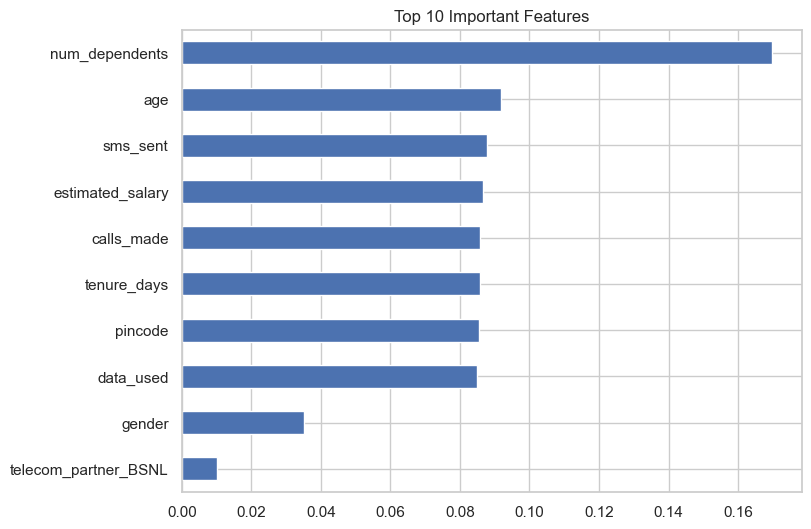

num_dependents          0.169857
age                     0.091688
sms_sent                0.087930
estimated_salary        0.086644
calls_made              0.085737
tenure_days             0.085722
pincode                 0.085421
data_used               0.084832
gender                  0.035197
telecom_partner_BSNL    0.010193
dtype: float64


In [17]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)
plt.figure(figsize=(8,6))
top_features.plot(kind='barh')
plt.title('Top 10 Important Features')
plt.gca().invert_yaxis()
plt.show()
print(top_features)

## Generate CHURN-FLAG Predictions & Risk Scores

In [18]:
X_full_scaled = scaler.transform(X)
df['CHURN_FLAG'] = rf_model.predict(X_full_scaled)
df['CHURN_RISK_SCORE'] = rf_model.predict_proba(X_full_scaled)[:,1]
df[['CHURN_FLAG', 'CHURN_RISK_SCORE']].head(10)

,CHURN_FLAG,CHURN_RISK_SCORE
0,0,0.080
1,0,0.115
2,1,0.855
3,1,0.760
4,0,0.060
5,0,0.060
6,0,0.105
7,1,0.735
8,0,0.250
9,0,0.070


## Compare Both Models Side-by-Side

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred), recall_score(y_test, y_pred_rf)],
    'F1 Score': [f1_score(y_test, y_pred), f1_score(y_test, y_pred_rf)],
    'ROC-AUC': [
        roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:,1])
    ]
})
print(results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.515161   0.204799  0.492063  0.289223  0.507377
1        Random Forest  0.789247   0.199280  0.016999  0.031327  0.500735


In [20]:
final_output = df[['CHURN_FLAG', 'CHURN_RISK_SCORE']].copy()
final_output.to_csv('churn_predictions.csv', index=False)
print("Saved! Sample:")
final_output.sort_values('CHURN_RISK_SCORE', ascending=False).head(10)

Saved! Sample:


,CHURN_FLAG,CHURN_RISK_SCORE
208693,1,0.990
119176,1,0.990
27502,1,0.985
92064,1,0.985
204711,1,0.985
152746,1,0.985
88766,1,0.985
126814,1,0.985
148349,1,0.980
162937,1,0.980


## Save the Trained Model

In [21]:
import joblib

joblib.dump(rf_model, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved!")

Model and scaler saved!


## ROC Curve Comparison

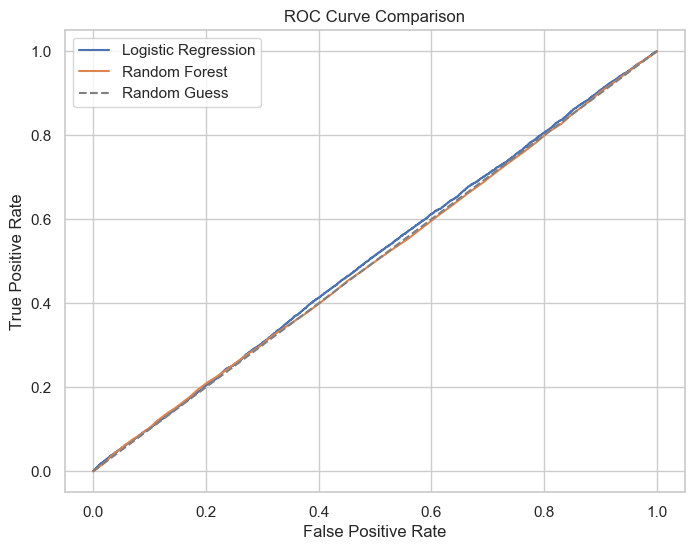

In [22]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, log_model.predict_proba(X_test_scaled)[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test_scaled)[:,1])

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

## Confusion Matrix Heatmap

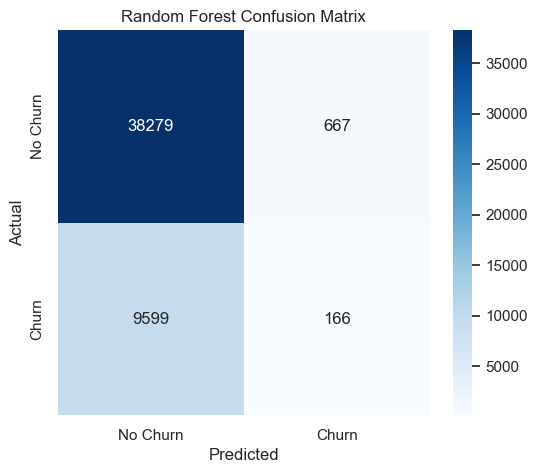

In [23]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

## Challenges Faced

1. **Column Naming Mismatch** — The initial code was written based on a business case document describing one set of columns (e.g. `Churn`, `Phone`), but the actual dataset had different column names and casing (e.g. `churn` lowercase, no `Phone` column at all). Had to inspect `df.columns.tolist()` and `df.dtypes` to identify the real schema before proceeding.

2. **Class Imbalance** — Churned customers were a minority class compared to non-churned customers, which could cause the model to be biased toward predicting "no churn." Addressed this using SMOTE (Synthetic Minority Oversampling Technique) to balance the training data.

3. **High Cardinality Categorical Features** — Columns like `state` and `city` had many unique categories, which increased dimensionality significantly after one-hot encoding. Had to be mindful of this when interpreting feature importance.

4. **Weak Individual Feature Correlations** — Many individual features (like specific state/city dummy variables) showed very low correlation with churn on their own, requiring the use of ensemble models like Random Forest to capture more complex, non-linear relationships instead of relying on simple linear correlation.

5. **Large Dataset Size** — With ~243,000+ rows, training models like Random Forest took noticeably longer, requiring parameter adjustments (e.g. `n_jobs=-1`, tuning `n_estimators`) to balance performance and training time.

6. **Balancing Model Interpretability vs. Performance** — Logistic Regression was easier to interpret but Random Forest generally performed better, requiring a trade-off discussion between explainability and accuracy for business stakeholders.